c:\Users\xan37\Downloads\ML_cardiac_prediction\chronos\..\functions.py:294: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f"D$_2$ vs log($\epsilon$) (D$_2$ plateau ≈ {plateau_average:.3f})")


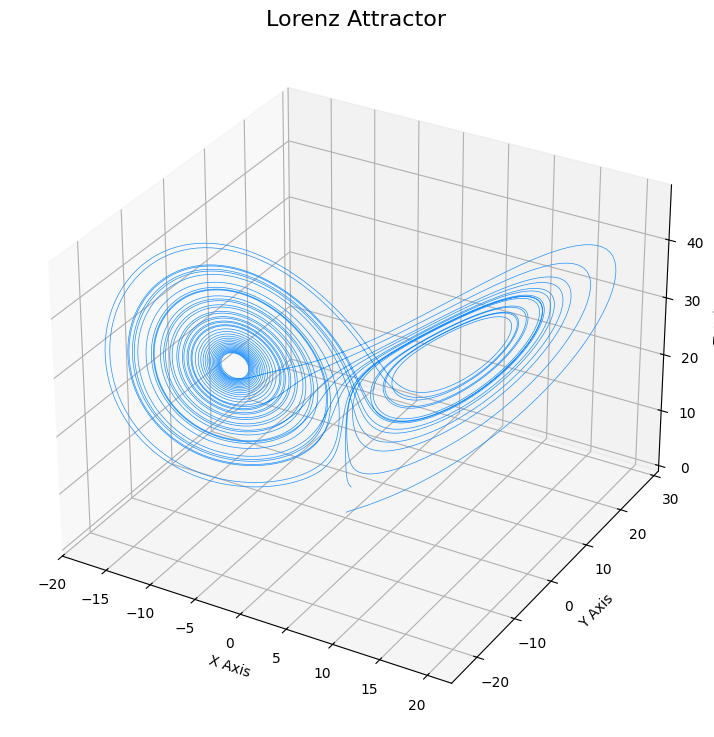

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import sys
sys.path.append("..")   # add parent directory to Python path
import functions

# Define the Lorenz attractor equations
def lorenz(state, t, sigma, beta, rho):
    x, y, z = state
    
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    
    return [dx, dy, dz]

# --- Parameters and Initial Conditions ---

# Standard Lorenz attractor parameters
sigma = 10.0
beta = 8.0 / 3.0
rho = 28.0

# Initial state [x, y, z]
initial_state = [0.1, 0.0, 0.0]

# Time points to solve for
# (start, stop, number_of_steps)
t = np.linspace(0, 40, 10000)

# --- Solve the Differential Equations ---

# Use odeint to solve the system
# It requires the function, initial state, time points, and arguments for the function
solution = odeint(lorenz, initial_state, t, args=(sigma, beta, rho))

# Extract the x, y, and z coordinates from the solution
x = solution[:, 0]
y = solution[:, 1]
z = solution[:, 2]

# --- Plot the Attractor ---

# Create a 3D plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectory
ax.plot(x, y, z, lw=0.5, color='dodgerblue')

# Add titles and labels
ax.set_title("Lorenz Attractor", fontsize=16)
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")

# Show the plot
plt.show()

In [17]:
x = solution[:2000,0]
window_size = 1000



TISEAN 3.0.0 (C) R. Hegger, H. Kantz, T. Schreiber (1998-2007)

lyap_k: Estimates the maximal Lyapunov exponent using the Kantz
	algorithm

Using output.dat as datafile, reading column 1
Use 2000 lines.
Opened output.dat.lyap for writing
epsilon= 3.025412e-002
epsilon= 5.380029e-002
epsilon= 9.567194e-002
epsilon= 1.701314e-001
epsilon= 3.025412e-001


np.float64(0.10217905000000001)

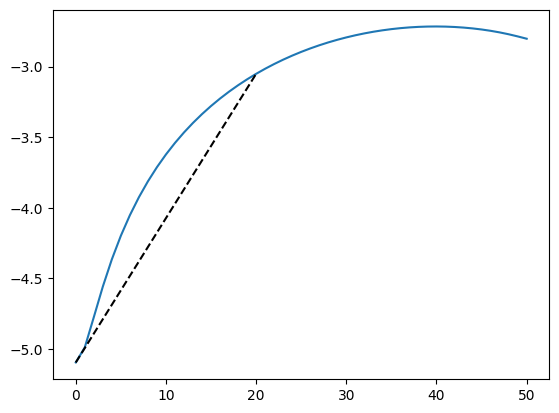

In [18]:
functions.plot_lya(x,0,20)

Best Slope Found: 0.1049
Segment Start X: 24.3719
Segment End X: 49.2462
R-squared of this segment: 0.9920


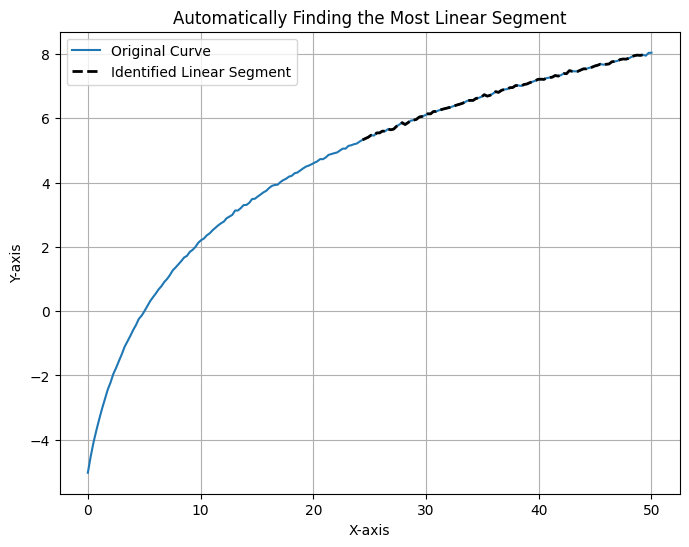

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. Create Sample Data (replace with your own) ---
x = np.linspace(0, 50, 200)
y = -5 + 4 * np.log1p(x * 0.5) + np.random.randn(len(x)) * 0.02

# --- 2. The Algorithm: Sliding Window Linear Regression ---

# Parameter to tune
window_size = 100

# Store the best result
best_slope = 0
best_r_squared = -1
best_window_indices = (0, 0)

# Slide the window across the data
for i in range(len(x) - window_size):
    x_window = x[i : i + window_size]
    y_window = y[i : i + window_size]
    
    result = stats.linregress(x_window, y_window)
    r_squared = result.rvalue**2
    
    if r_squared > best_r_squared:
        best_r_squared = r_squared
        best_slope = result.slope
        best_window_indices = (i, i + window_size)

# --- 3. Output and Visualize the Results ---

# Get the start and end index from our results
start_index = best_window_indices[0]
# The end index needs -1 because slicing goes up to (but not including) the end
end_index = best_window_indices[1] - 1 

# Get the corresponding x-values
start_x = x[start_index]
end_x = x[end_index]

print(f"Best Slope Found: {best_slope:.4f}")
print(f"Segment Start X: {start_x:.4f}")
print(f"Segment End X: {end_x:.4f}")
print(f"R-squared of this segment: {best_r_squared:.4f}")


# --- 4. Plotting ---
plt.figure(figsize=(8, 6))
plt.plot(x, y, label='Original Curve')

# Get the data points of the best-fit segment to plot the line
x_best = x[start_index : end_index + 1]
y_best = y[start_index : end_index + 1]

plt.plot(x_best, y_best, 'k--', linewidth=2, label='Identified Linear Segment')

plt.legend()
plt.title("Automatically Finding the Most Linear Segment")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.show()